# Nifty 50 Market Regime Detection using Gaussian Mixture Models (GMM)

This project detects the "mood" or "regime" of the Indian stock market (Nifty 50 index) automatically using an unsupervised machine learning algorithm known as the Gaussian Mixture Model (GMM). Instead of predicting exact prices, the model segments the market history into **Bull (Uptrend)**, **Bear (Downtrend)**, and **Sideways (Ranging)** regimes without any prior human labeling.

**Key Concepts Used:**
- **Log Returns:** Symmetric and additive measure of market performance.
- **Rolling Volatility:** 20-day standard deviation of log returns.
- **RSI & MA Ratios:** Momentum and trend strength indicators.
- **Gaussian Mixture Model (GMM):** Gives probabilistic (soft) assignments instead of hard labels (unlike K-Means), capturing the market's transitions and uncertainty elegantly.

### Step 1: Import All Libraries
We use `yfinance` to grab data, `scikit-learn` for GMM and scaling, and `matplotlib`/`seaborn` for visualization.

In [1]:
# !pip install yfinance pandas numpy scikit-learn matplotlib seaborn

import yfinance            as yf
import pandas              as pd
import numpy               as np
import matplotlib.pyplot   as plt
import matplotlib.patches  as mpatches
import seaborn             as sns
import warnings

from sklearn.mixture        import GaussianMixture
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics        import silhouette_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded!')
print('GaussianMixture model is ready.')

All libraries loaded!
GaussianMixture model is ready.


### Step 2: Download Nifty 50 Historical Data
We fetch 10 years of Nifty 50 data from Yahoo Finance. The ticker for Nifty 50 is `^NSEI`.

In [2]:
TICKER     = '^NSEI'
START_DATE = '2014-01-01'
END_DATE   = '2024-01-01'

print(f'Downloading {TICKER} from {START_DATE} to {END_DATE} ...')
df = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)

# yfinance sometimes returns MultiIndex columns — flatten them
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f'Downloaded {len(df)} trading days')
print(f'Date range : {df.index[0].date()}  →  {df.index[-1].date()}')
print(f'Nifty start: {df["Close"].iloc[0]:,.0f} points')
print(f'Nifty end  : {df["Close"].iloc[-1]:,.0f} points')
print()
df.head()

Downloaded 2453 trading days
Date range : 2014-01-02  →  2023-12-29
Nifty start: 6,221 points
Nifty end  : 21,731 points



Price,Close,High,Low,Open,Volume
Date,,,,,
2014-01-02,6221.149902,6358.299805,6211.299805,6301.250000,158100
2014-01-03,6211.149902,6221.700195,6171.250000,6194.549805,139000
2014-01-06,6191.450195,6224.700195,6170.250000,6220.850098,118300
2014-01-07,6162.250000,6221.500000,6144.750000,6203.899902,138600
2014-01-08,6174.600098,6192.100098,6160.350098,6178.049805,146900


### Step 3: Clean the Data
Remove any missing values (NaN) that could crash our ML algorithms.

In [3]:
# Check for any missing values
print('Missing values per column:')
print(df.isnull().sum())

# Remove rows with any missing values
df.dropna(inplace=True)

print(f'\nClean rows remaining: {len(df)}')
print('Data is ready!')

Missing values per column:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Clean rows remaining: 2453
Data is ready!


### Step 4: Plot Raw Nifty 50 Price
Visualizing the raw index with key historical events annotated (e.g., Demonetisation, COVID-19 Crash).

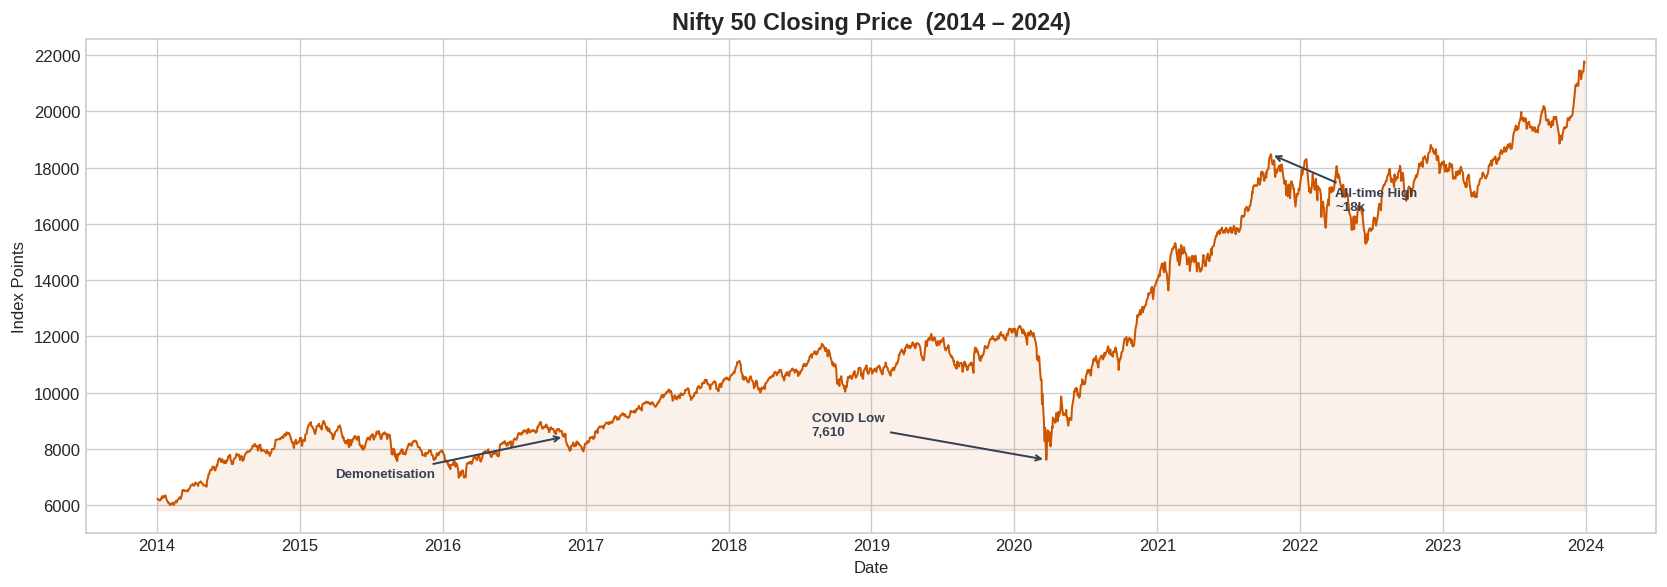

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df['Close'], color='#CC5500', linewidth=1.2)
ax.fill_between(df.index, df['Close'], df['Close'].min()*0.97, alpha=0.08, color='#CC5500')

# Annotate key Indian market events
events = {
    '2016-11-08': ('Demonetisation',  8432,  '2015-04-01',  7000),
    '2020-03-23': ('COVID Low\n7,610', 7610,  '2018-08-01',  8500),
    '2021-10-18': ('All-time High\n~18k', 18477,'2022-04-01',16500),
}
for date, (label, y, tx, ty) in events.items():
    ax.annotate(label,
        xy=(pd.Timestamp(date), y),
        xytext=(pd.Timestamp(tx), ty),
        arrowprops=dict(arrowstyle='->', color='#374151', lw=1.2),
        fontsize=8, color='#374151', fontweight='bold')

ax.set_title('Nifty 50 Closing Price  (2014 – 2024)', fontsize=14, fontweight='bold')
ax.set_ylabel('Index Points')
ax.set_xlabel('Date')
plt.tight_layout()
plt.savefig('01_nifty50_raw.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 5: Feature Engineering
Raw prices aren't sufficient. We calculate four powerful financial metrics to feed into our model:
1. **Log Returns:** Better statistical properties than simple percentage returns.
2. **20-Day Rolling Volatility:** Represents risk and jumpiness.
3. **RSI (14-day):** A momentum indicator bounded between 0 and 100.
4. **Moving Average Ratio (50d/200d):** Compares short-term trend vs long-term trend.

In [5]:
# Feature 1: Log daily return
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))

# Feature 2: Rolling 20-day volatility of log returns
df['volatility_20d'] = df['log_return'].rolling(window=20).std()

# Feature 3: RSI — 14-day Relative Strength Index
def compute_rsi(series, period=14):
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = (-delta).clip(lower=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs       = avg_gain / avg_loss
    rsi      = 100 - (100 / (1 + rs))
    return rsi

df['rsi'] = compute_rsi(df['Close'])

# Feature 4: Moving Average Ratio (50-day / 200-day)
df['ma_50']    = df['Close'].rolling(window=50).mean()
df['ma_200']   = df['Close'].rolling(window=200).mean()
df['ma_ratio'] = df['ma_50'] / df['ma_200']

# Drop rows where any feature is NaN
df_clean = df.dropna().copy()

print(f'Features created!')
print(f'Rows after dropping NaN: {len(df_clean)}')
print(f'Date range: {df_clean.index[0].date()}  →  {df_clean.index[-1].date()}')
print()
print('Feature statistics:')
print(df_clean[['log_return','volatility_20d','rsi','ma_ratio']].describe().round(4))

Features created!
Rows after dropping NaN: 2254
Date range: 2014-10-31  →  2023-12-29

Feature statistics:
Price  log_return  volatility_20d        rsi   ma_ratio
count   2254.0000       2254.0000  2254.0000  2254.0000
mean       0.0004          0.0091    55.6729     1.0327
std        0.0107          0.0055    17.5051     0.0589
min       -0.1390          0.0032     6.6798     0.8177
25%       -0.0045          0.0061    42.6479     0.9957
50%        0.0007          0.0079    55.6922     1.0376
75%        0.0061          0.0103    68.5132     1.0646
max        0.0840          0.0570    99.5824     1.1970


### Step 6: Visualizing the Engineered Features
Plotting these features helps us visually confirm they make sense.

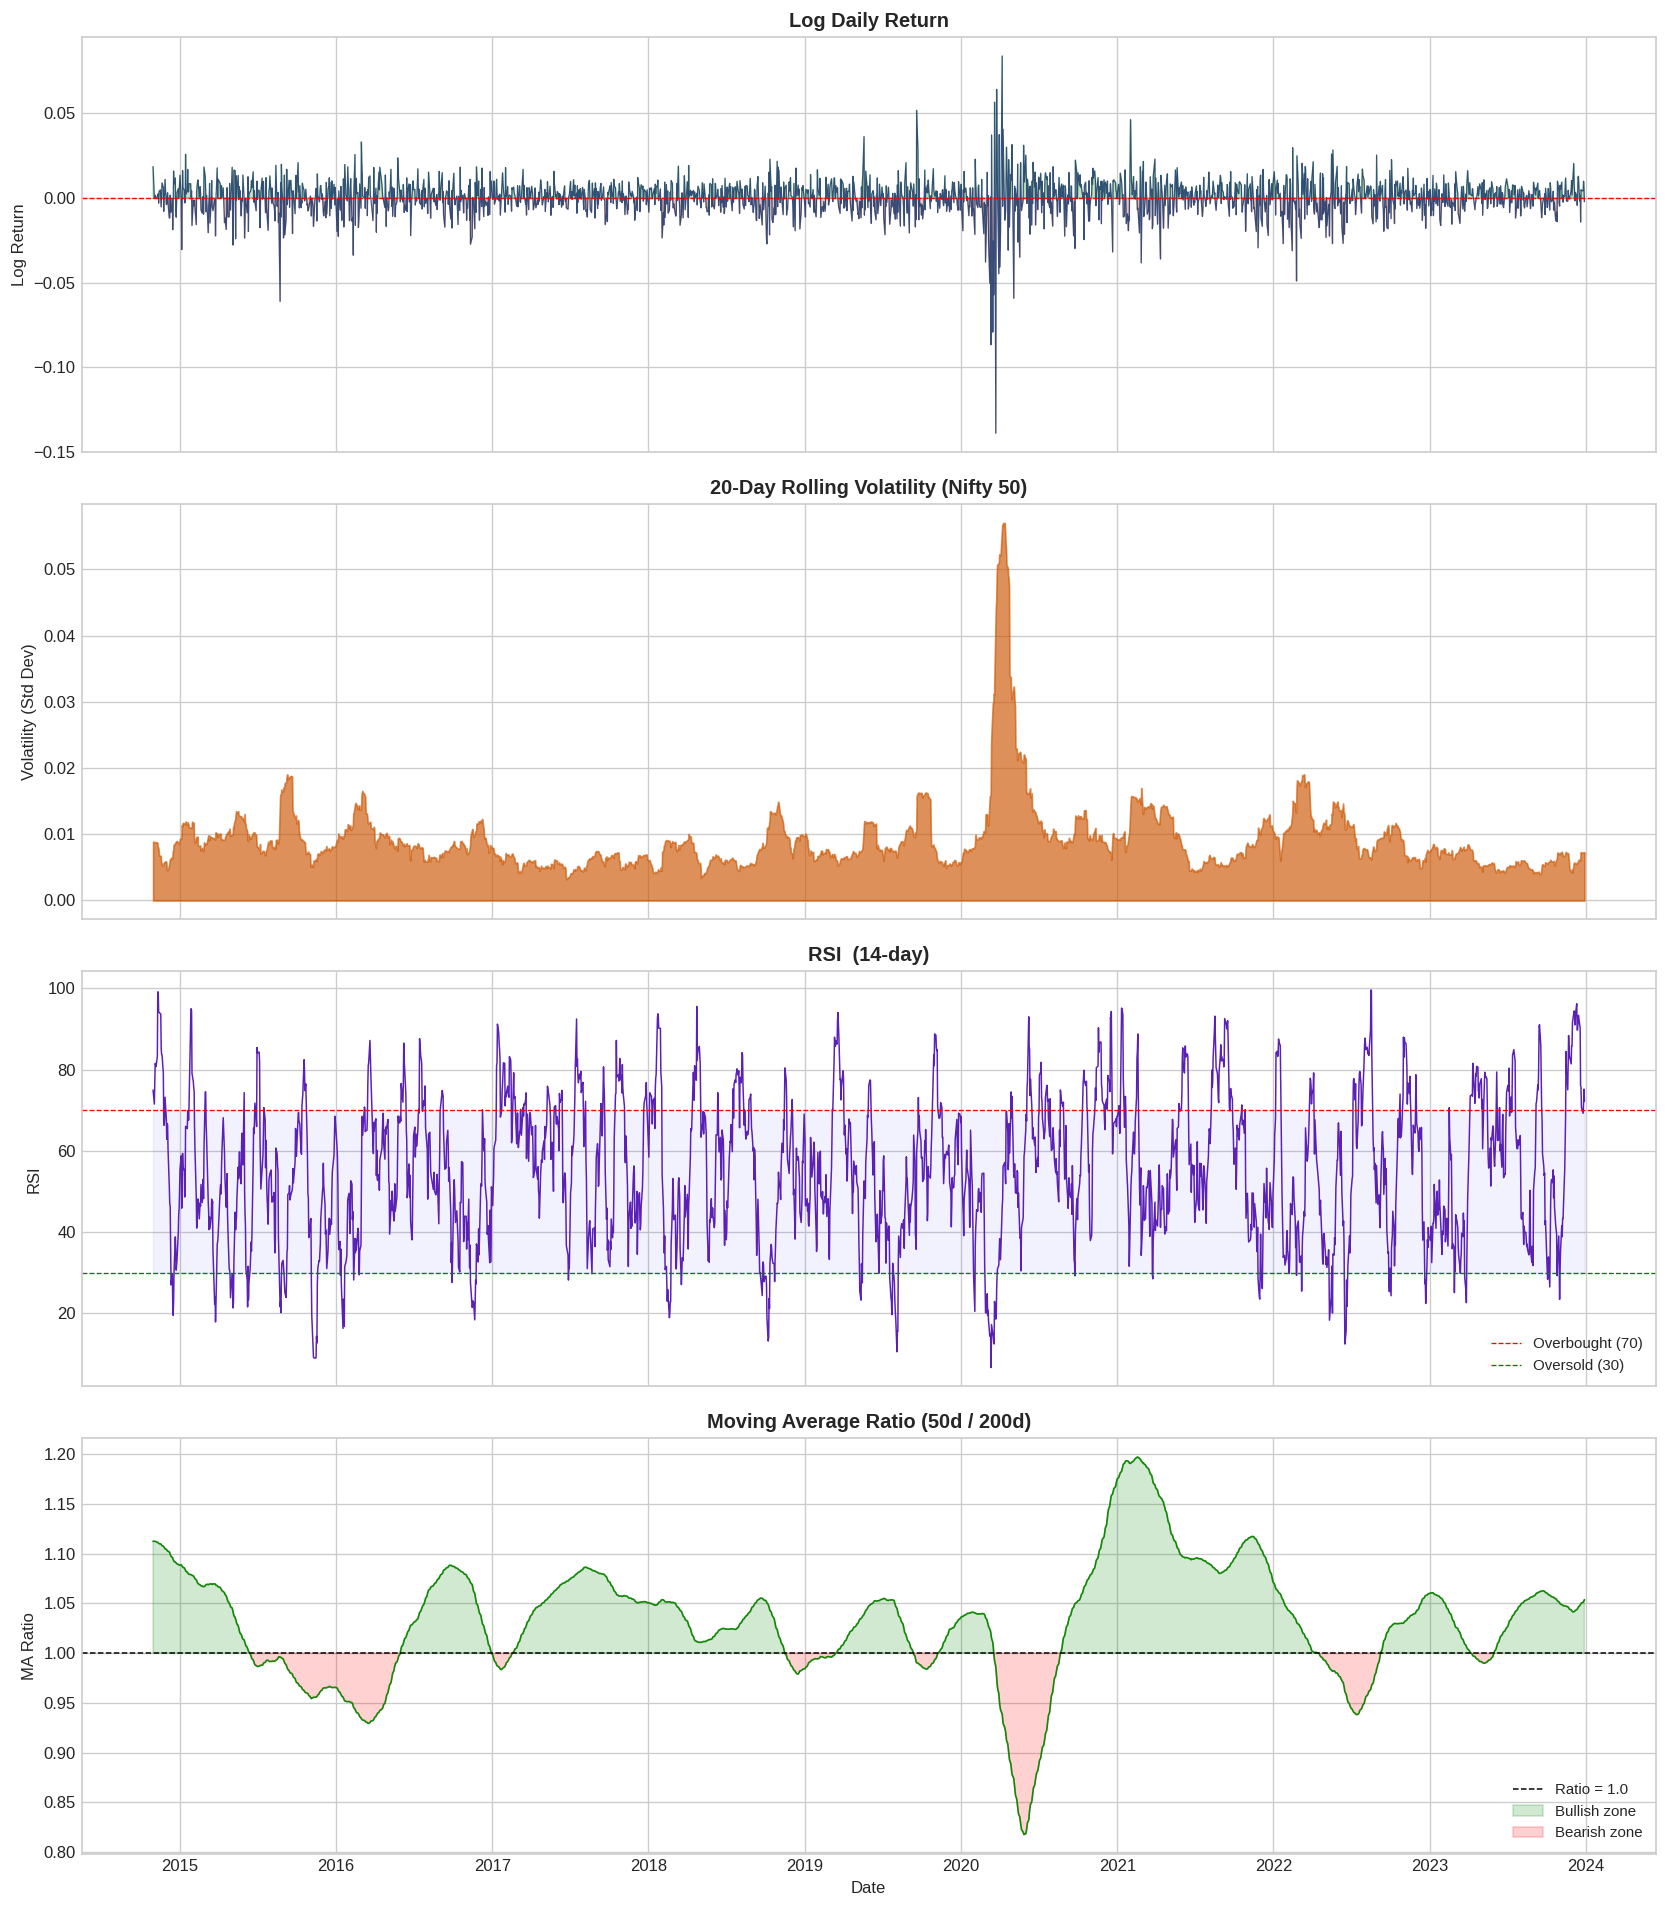

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# 1. Log returns
axes[0].plot(df_clean.index, df_clean['log_return'], color='#1B3A6B', lw=0.7, alpha=0.85)
axes[0].axhline(0, color='red', lw=0.8, linestyle='--')
axes[0].fill_between(df_clean.index, df_clean['log_return'], 0,
    where=df_clean['log_return']>=0, alpha=0.25, color='#138808')
axes[0].fill_between(df_clean.index, df_clean['log_return'], 0,
    where=df_clean['log_return']<0, alpha=0.25, color='#991B1B')
axes[0].set_title('Log Daily Return', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Log Return')

# 2. 20-day rolling volatility
axes[1].fill_between(df_clean.index, df_clean['volatility_20d'], alpha=0.65, color='#CC5500')
axes[1].set_title('20-Day Rolling Volatility (Nifty 50)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Volatility (Std Dev)')

# 3. RSI
axes[2].plot(df_clean.index, df_clean['rsi'], color='#5B21B6', lw=0.9)
axes[2].axhline(70, color='red',   lw=0.8, linestyle='--', label='Overbought (70)')
axes[2].axhline(30, color='green', lw=0.8, linestyle='--', label='Oversold (30)')
axes[2].fill_between(df_clean.index, 30, 70, alpha=0.05, color='blue')
axes[2].set_title('RSI  (14-day)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('RSI')
axes[2].legend(fontsize=9, loc='lower right')

# 4. MA Ratio
axes[3].plot(df_clean.index, df_clean['ma_ratio'], color='#138808', lw=1.0)
axes[3].axhline(1.0, color='black', lw=0.9, linestyle='--', label='Ratio = 1.0')
axes[3].fill_between(df_clean.index, df_clean['ma_ratio'], 1.0,
    where=df_clean['ma_ratio']>=1.0, alpha=0.18, color='green', label='Bullish zone')
axes[3].fill_between(df_clean.index, df_clean['ma_ratio'], 1.0,
    where=df_clean['ma_ratio']<1.0,  alpha=0.18, color='red',   label='Bearish zone')
axes[3].set_title('Moving Average Ratio (50d / 200d)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('MA Ratio')
axes[3].set_xlabel('Date')
axes[3].legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('02_nifty50_features.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 7: Feature Scaling
We standardize features (mean=0, std=1) so that GMM treats all metrics equally.

In [7]:
FEATURES = ['log_return', 'volatility_20d', 'rsi', 'ma_ratio']

X = df_clean[FEATURES].copy()

# Scale features to mean=0, std=1
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix shape: {X_scaled.shape}')
print(f'  Rows = {X_scaled.shape[0]} trading days')
print(f'  Cols = {X_scaled.shape[1]} features')
print()
print('Scaled feature means (should be ~0):')
print(np.round(X_scaled.mean(axis=0), 4))
print('Scaled feature stds  (should be ~1):')
print(np.round(X_scaled.std(axis=0),  4))

Feature matrix shape: (2254, 4)
  Rows = 2254 trading days
  Cols = 4 features

Scaled feature means (should be ~0):
[ 0.  0.  0. -0.]
Scaled feature stds  (should be ~1):
[1. 1. 1. 1.]


### Step 8: Choosing Optimal Number of Clusters (K)
We use the Bayesian Information Criterion (BIC) to find the "elbow" point. The lower the score, the better the fit while penalizing complexity.

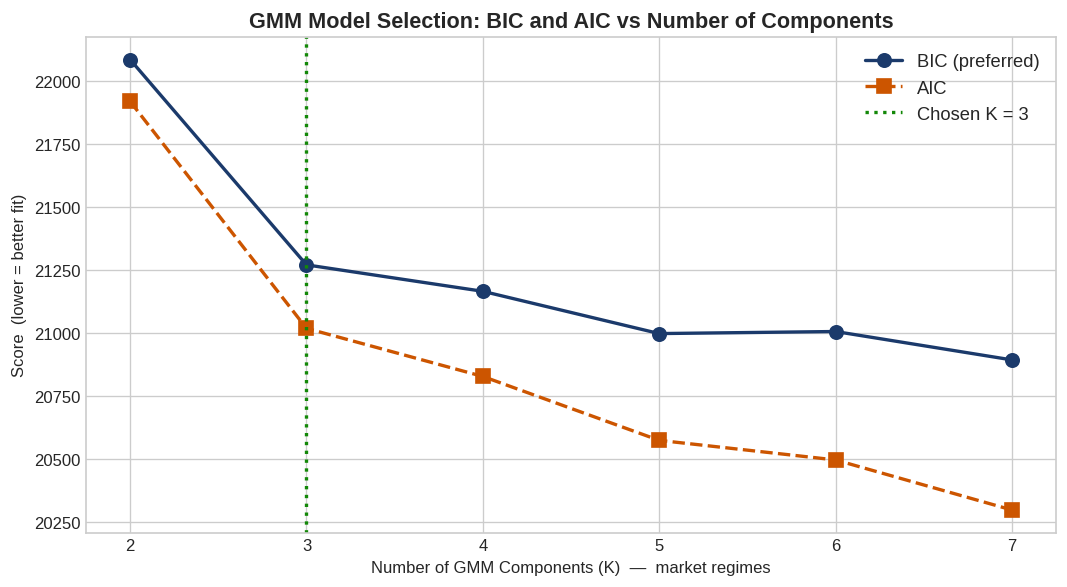

BIC scores by K:
  K = 2  →  BIC = 22,084.8
  K = 3  →  BIC = 21,270.8
  K = 4  →  BIC = 21,165.9
  K = 5  →  BIC = 20,998.4
  K = 6  →  BIC = 21,006.5
  K = 7  →  BIC = 20,894.0


In [8]:
bic_scores = []
aic_scores = []
k_range    = range(2, 8)

for k in k_range:
    gmm_test = GaussianMixture(
        n_components = k,
        covariance_type = 'full',   # each component has its own shape
        random_state = 42,
        n_init = 5                  # try 5 random starts, keep the best
    )
    gmm_test.fit(X_scaled)
    bic_scores.append(gmm_test.bic(X_scaled))
    aic_scores.append(gmm_test.aic(X_scaled))

# Plot BIC and AIC
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_range, bic_scores, 'o-', color='#1B3A6B', lw=2, ms=8, label='BIC (preferred)')
ax.plot(k_range, aic_scores, 's--', color='#CC5500', lw=2, ms=8, label='AIC')
ax.axvline(x=3, color='#138808', lw=2, linestyle=':', label='Chosen K = 3')
ax.set_title('GMM Model Selection: BIC and AIC vs Number of Components',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of GMM Components (K)  —  market regimes')
ax.set_ylabel('Score  (lower = better fit)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('03_gmm_bic_aic.png', dpi=150, bbox_inches='tight')
plt.show()

print('BIC scores by K:')
for k, b in zip(k_range, bic_scores):
    print(f'  K = {k}  →  BIC = {b:,.1f}')

### Step 9: Fit the Final GMM Model
Using `n_components = 3`, we fit our model. We extract both the hard labels and the soft probabilities.

In [9]:
gmm = GaussianMixture(
    n_components    = 3,
    covariance_type = 'full',  # each regime has its own covariance shape
    random_state    = 42,
    n_init          = 10,      # run 10 random initialisations, keep best
    max_iter        = 200      # maximum EM iterations
)

gmm.fit(X_scaled)

# Hard label: most likely regime for each day
df_clean['gmm_cluster'] = gmm.predict(X_scaled)

# Soft labels: probability of each regime for each day
proba = gmm.predict_proba(X_scaled)
df_clean['prob_regime_0'] = proba[:, 0]
df_clean['prob_regime_1'] = proba[:, 1]
df_clean['prob_regime_2'] = proba[:, 2]

print(f'GMM converged: {gmm.converged_}')
print(f'EM iterations: {gmm.n_iter_}')
print(f'Final BIC    : {gmm.bic(X_scaled):,.1f}')
print(f'Final AIC    : {gmm.aic(X_scaled):,.1f}')
print()
print('Days assigned to each cluster:')
print(df_clean['gmm_cluster'].value_counts().sort_index())

GMM converged: True
EM iterations: 16
Final BIC    : 21,270.8
Final AIC    : 21,019.1

Days assigned to each cluster:
gmm_cluster
0      64
1    1400
2     790
Name: count, dtype: int64


### Step 10: Assign Meaningful Names (Bull, Bear, Sideways)
We inspect the cluster averages to properly name them based on financial intuition.

In [10]:
# Summarise the original (unscaled) features per cluster
summary = df_clean.groupby('gmm_cluster').agg(
    avg_log_return  = ('log_return',    'mean'),
    avg_volatility  = ('volatility_20d','mean'),
    avg_rsi         = ('rsi',           'mean'),
    avg_ma_ratio    = ('ma_ratio',       'mean'),
    count           = ('log_return',     'count')
).round(5)

print('Cluster Summary (read this to decide regime names):')
print(summary)
print()
print('Rule: highest avg_log_return = Bull')
print('      lowest  avg_log_return = Bear  (will also have highest avg_volatility)')
print('      middle  = Sideways')

# Sort clusters by average log return to find Bull, Bear, Sideways
sorted_c = summary.sort_values('avg_log_return')

# Map cluster numbers to regime names
regime_map = {
    sorted_c.index[0]: 'Bear',      # lowest avg log return
    sorted_c.index[1]: 'Sideways',  # middle log return
    sorted_c.index[2]: 'Bull',      # highest avg log return
}

df_clean['regime'] = df_clean['gmm_cluster'].map(regime_map)

# Also name the probability columns correctly
for cluster_num, regime_name in regime_map.items():
    df_clean[f'prob_{regime_name}'] = df_clean[f'prob_regime_{cluster_num}']

print()
print('Regime assigned! Counts per regime:')
print(df_clean['regime'].value_counts())

Cluster Summary (read this to decide regime names):
             avg_log_return  avg_volatility   avg_rsi  avg_ma_ratio  count
gmm_cluster                                                               
0                  -0.00361         0.03222  48.50473       0.89989     64
1                   0.00074         0.00671  58.04612       1.03589   1400
2                   0.00023         0.01152  52.04803       1.03778    790

Rule: highest avg_log_return = Bull
      lowest  avg_log_return = Bear  (will also have highest avg_volatility)
      middle  = Sideways

Regime assigned! Counts per regime:
regime
Bull        1400
Sideways     790
Bear          64
Name: count, dtype: int64


### Step 11: Evaluate the Clusters
Check silhouette scores, financial reality, and regime certainty levels.

In [11]:
# --- 1. Silhouette Score ---
labels      = df_clean['gmm_cluster'].values
sil         = silhouette_score(X_scaled, labels)
print(f'Silhouette Score: {sil:.4f}')
if sil > 0.35:
    print('  → Good cluster separation!')
elif sil > 0.25:
    print('  → Acceptable for financial time series data')
else:
    print('  → Clusters may overlap — try different features or K')

# --- 2. Financial Sense Check ---
print()
print('Financial Sense Check:')
fin_check = df_clean.groupby('regime').agg(
    avg_return    = ('log_return',    lambda x: round(x.mean()*100, 4)),
    avg_vol       = ('volatility_20d',lambda x: round(x.mean()*100, 4)),
    avg_rsi       = ('rsi',           lambda x: round(x.mean(), 2)),
    avg_ma_ratio  = ('ma_ratio',      lambda x: round(x.mean(), 4)),
    days          = ('log_return',    'count')
)
print(fin_check)

# --- 3. Uncertainty Analysis (unique to GMM) ---
print()
print('Regime Certainty (avg max probability per regime):')
for regime in ['Bull', 'Bear', 'Sideways']:
    subset = df_clean[df_clean['regime'] == regime]
    max_prob = proba[df_clean['regime'] == regime].max(axis=1).mean()
    print(f'  {regime:<10}: avg certainty = {max_prob:.3f} ({max_prob*100:.1f}%)')

print()
print('Days with low certainty (max prob < 0.6) — transition days:')
max_prob_all = proba.max(axis=1)
uncertain_days = (max_prob_all < 0.60).sum()
print(f'  {uncertain_days} transition days  ({uncertain_days/len(df_clean)*100:.1f}% of all days)')

Silhouette Score: 0.1582
  → Clusters may overlap — try different features or K

Financial Sense Check:
          avg_return  avg_vol  avg_rsi  avg_ma_ratio  days
regime                                                    
Bear         -0.3608   3.2223    48.50        0.8999    64
Bull          0.0737   0.6710    58.05        1.0359  1400
Sideways      0.0225   1.1518    52.05        1.0378   790

Regime Certainty (avg max probability per regime):
  Bull      : avg certainty = 0.890 (89.0%)
  Bear      : avg certainty = 0.954 (95.4%)
  Sideways  : avg certainty = 0.903 (90.3%)

Days with low certainty (max prob < 0.6) — transition days:
  129 transition days  (5.7% of all days)


### Step 12: Visualizing Nifty 50 Regimes
Plotting the colored background regions for Bull, Bear, and Sideways regimes.

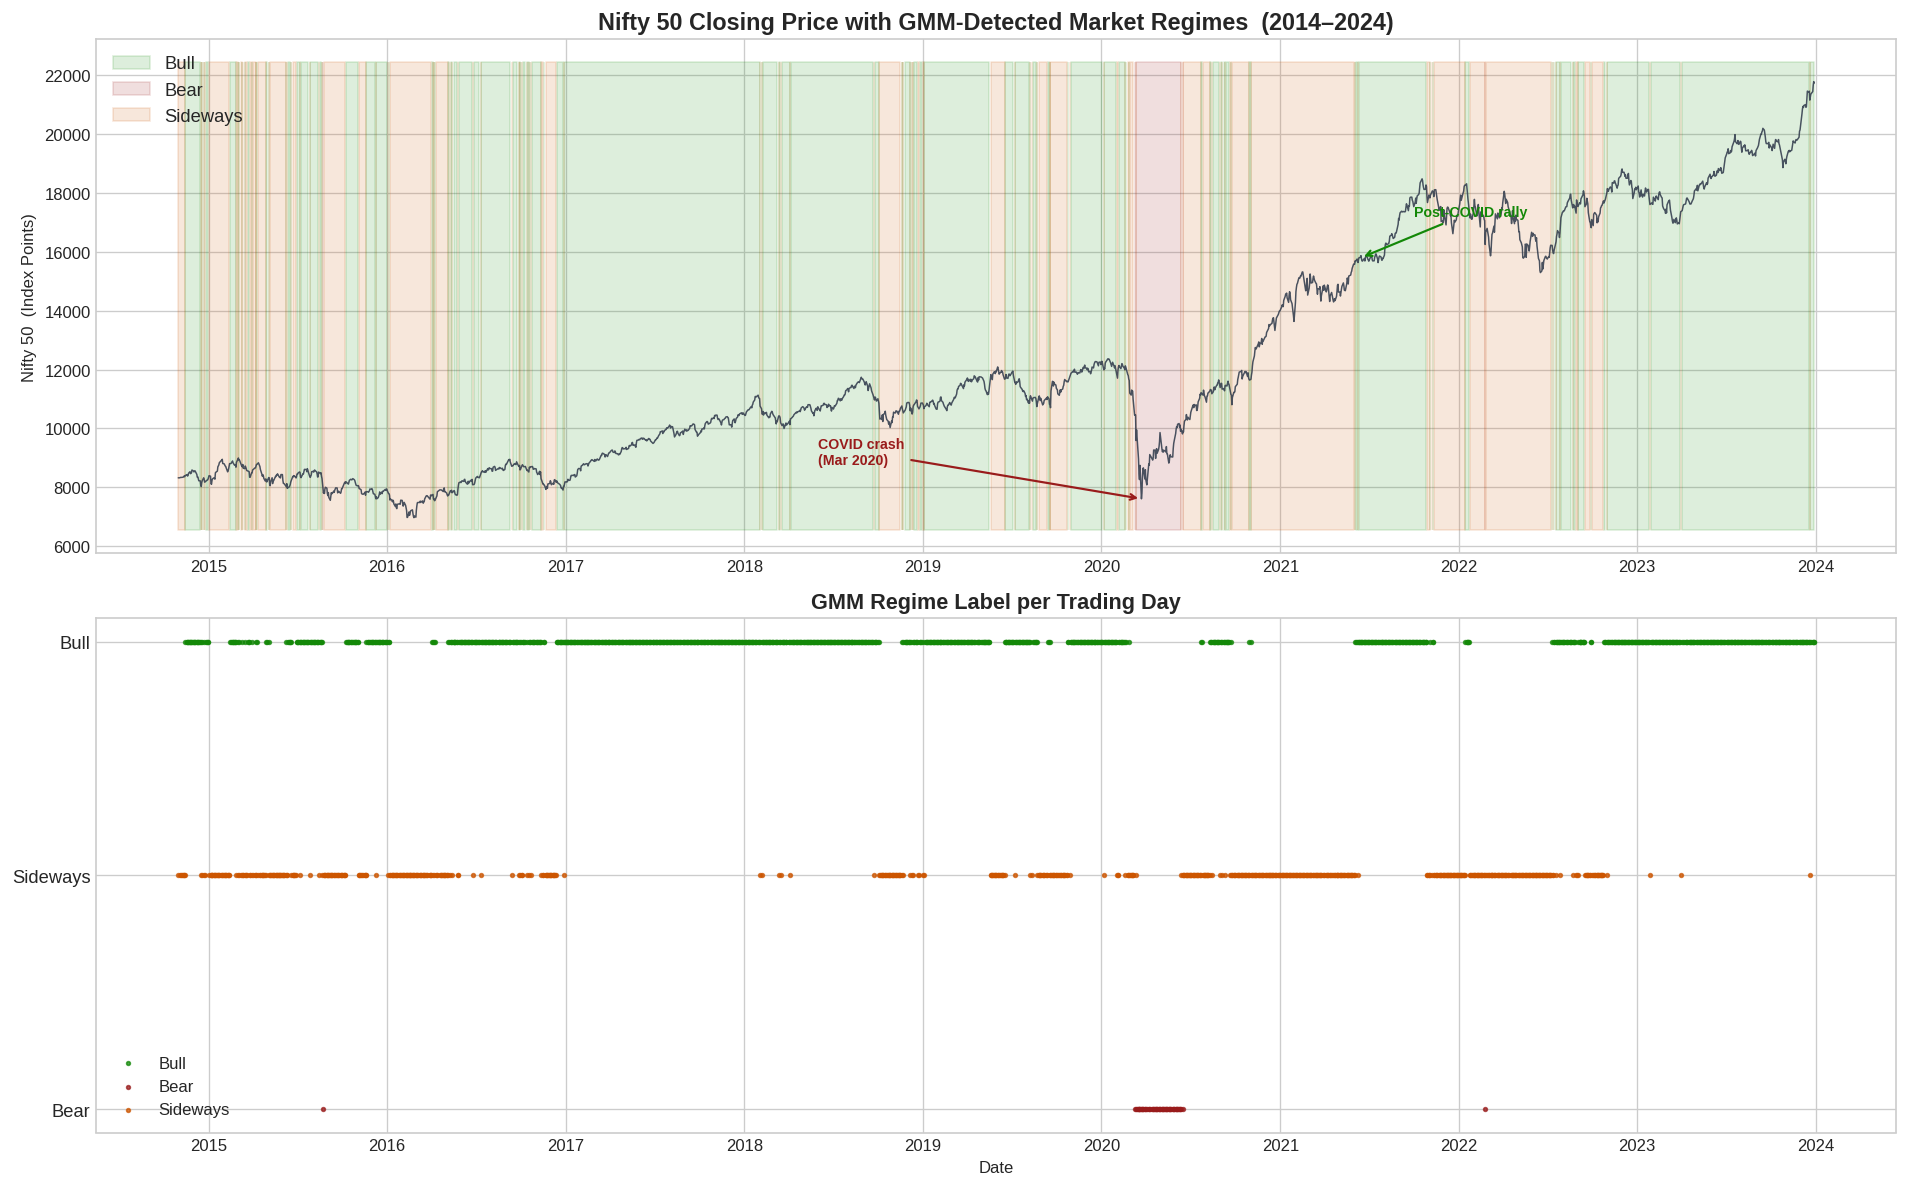

In [12]:
regime_palette = {'Bull':'#138808', 'Bear':'#991B1B', 'Sideways':'#CC5500'}

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ── Top: Price line with coloured background per regime ──
axes[0].plot(df_clean.index, df_clean['Close'], color='#374151', lw=0.9, alpha=0.9)

y_min = df_clean['Close'].min() * 0.94
y_max = df_clean['Close'].max() * 1.03
for regime, color in regime_palette.items():
    mask = df_clean['regime'] == regime
    axes[0].fill_between(df_clean.index, y_min, y_max,
                         where=mask, alpha=0.14, color=color, label=regime)

# Key event annotations
axes[0].annotate('COVID crash\n(Mar 2020)', xy=(pd.Timestamp('2020-03-23'), 7610),
    xytext=(pd.Timestamp('2018-06-01'), 8800),
    arrowprops=dict(arrowstyle='->', color='#991B1B', lw=1.3),
    fontsize=8.5, color='#991B1B', fontweight='bold')
axes[0].annotate('Post-COVID rally', xy=(pd.Timestamp('2021-06-15'), 15800),
    xytext=(pd.Timestamp('2021-10-01'), 17200),
    arrowprops=dict(arrowstyle='->', color='#138808', lw=1.3),
    fontsize=8.5, color='#138808', fontweight='bold')

axes[0].set_title('Nifty 50 Closing Price with GMM-Detected Market Regimes  (2014–2024)',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nifty 50  (Index Points)')
axes[0].legend(fontsize=11, loc='upper left')

# ── Bottom: Regime label timeline ──
regime_num = df_clean['regime'].map({'Bear':0,'Sideways':1,'Bull':2})
for regime, color in regime_palette.items():
    mask = df_clean['regime'] == regime
    axes[1].scatter(df_clean.index[mask], regime_num[mask],
                    c=color, s=5, alpha=0.75, label=regime)

axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(['Bear', 'Sideways', 'Bull'], fontsize=11)
axes[1].set_title('GMM Regime Label per Trading Day', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('04_nifty50_regime_price.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 13: Regime Probabilities (Soft Boundaries)
The magic of GMM vs K-Means is showing *uncertainty* (probabilities) rather than hard edges.

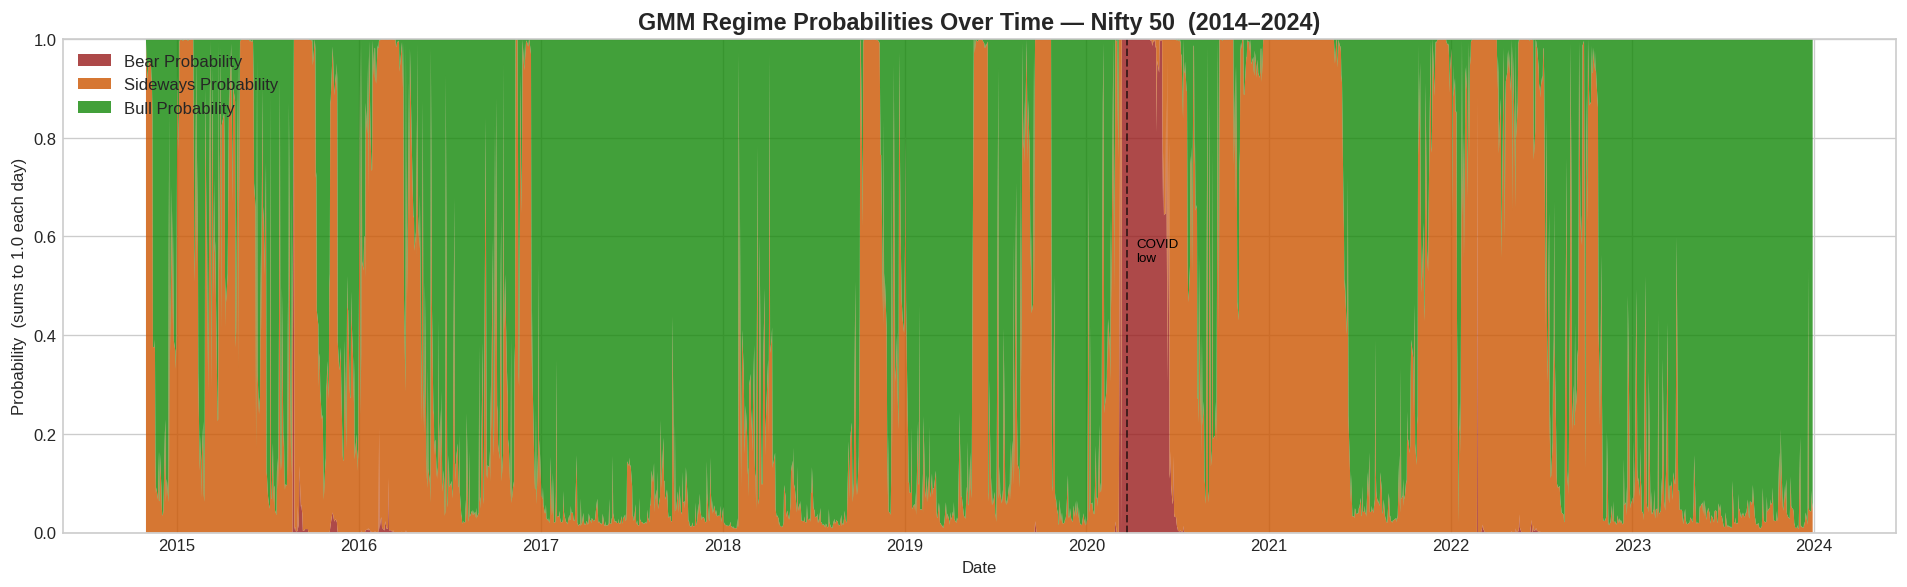

This chart is unique to GMM — K-Means cannot produce this!


In [13]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.stackplot(
    df_clean.index,
    df_clean['prob_Bear'],
    df_clean['prob_Sideways'],
    df_clean['prob_Bull'],
    labels  = ['Bear Probability', 'Sideways Probability', 'Bull Probability'],
    colors  = ['#991B1B', '#CC5500', '#138808'],
    alpha   = 0.80
)

ax.set_title('GMM Regime Probabilities Over Time — Nifty 50  (2014–2024)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Probability  (sums to 1.0 each day)')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=10)
ax.set_ylim(0, 1)

# Mark COVID crash
ax.axvline(pd.Timestamp('2020-03-23'), color='black', lw=1.2, linestyle='--', alpha=0.6)
ax.text(pd.Timestamp('2020-04-10'), 0.55, 'COVID\nlow', fontsize=8, color='black')

plt.tight_layout()
plt.savefig('05_regime_probability_stack.png', dpi=150, bbox_inches='tight')
plt.show()
print('This chart is unique to GMM — K-Means cannot produce this!')

### Step 14: Volatility Deep Dive
Comparing how volatile each regime is. Bear regimes should be highly volatile.

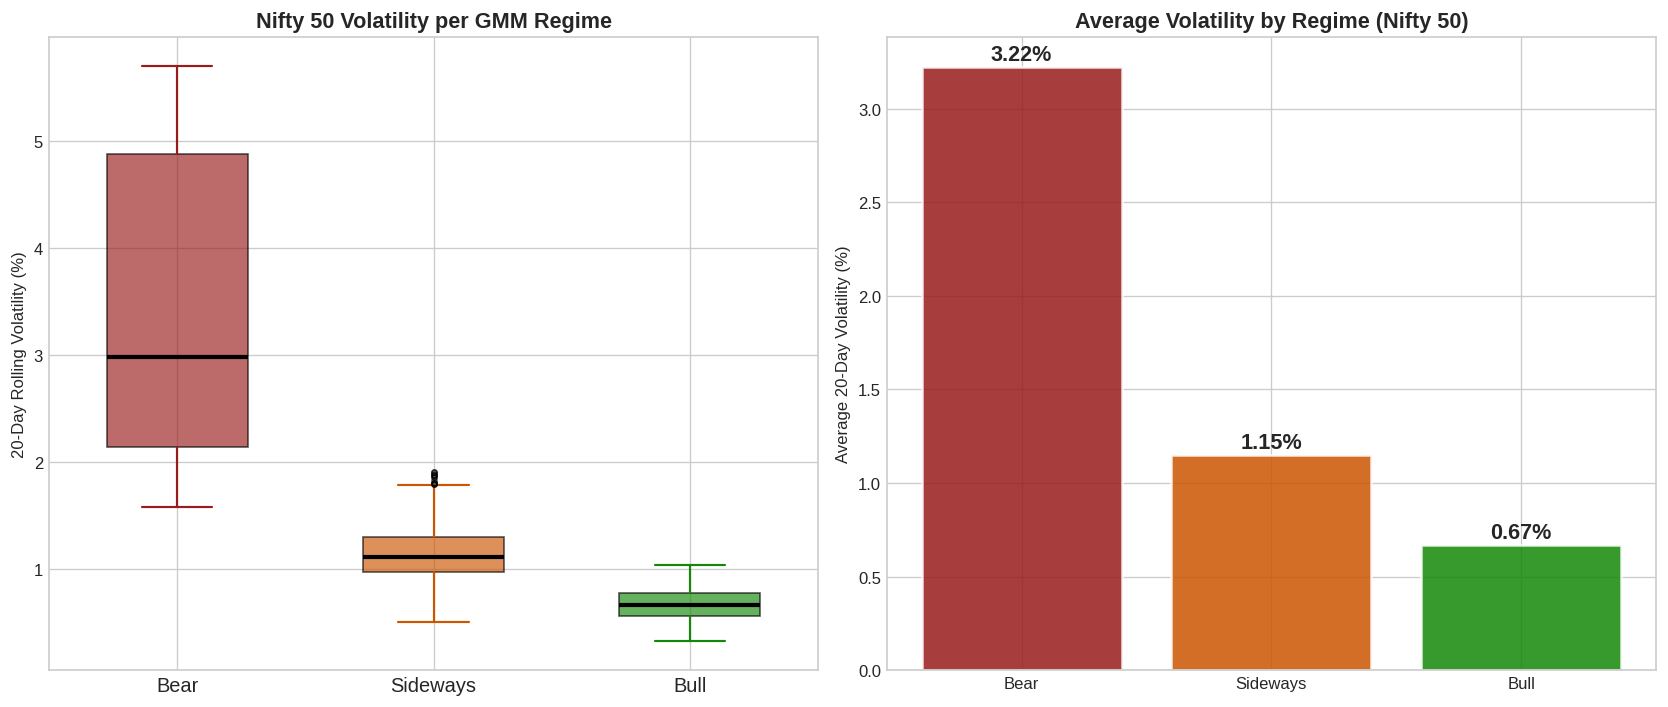

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

order  = ['Bear', 'Sideways', 'Bull']
colors = ['#991B1B', '#CC5500', '#138808']

# Box plot
for i, (regime, color) in enumerate(zip(order, colors)):
    data = df_clean[df_clean['regime'] == regime]['volatility_20d'] * 100
    axes[0].boxplot(data, positions=[i], widths=0.55,
        patch_artist=True,
        boxprops      = dict(facecolor=color, alpha=0.65),
        medianprops   = dict(color='black', lw=2.5),
        whiskerprops  = dict(color=color, lw=1.3),
        capprops      = dict(color=color, lw=1.3),
        flierprops    = dict(marker='.', color=color, alpha=0.4))

axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(order, fontsize=12)
axes[0].set_title('Nifty 50 Volatility per GMM Regime', fontsize=13, fontweight='bold')
axes[0].set_ylabel('20-Day Rolling Volatility (%)')

# Bar chart: average volatility
avg_vol = df_clean.groupby('regime')['volatility_20d'].mean().reindex(order) * 100
bars = axes[1].bar(order, avg_vol.values, color=colors, alpha=0.85,
                   edgecolor='white', lw=1.5)
for bar, val in zip(bars, avg_vol.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.2f}%', ha='center', va='bottom',
                 fontweight='bold', fontsize=13)

axes[1].set_title('Average Volatility by Regime (Nifty 50)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average 20-Day Volatility (%)')

plt.tight_layout()
plt.savefig('06_volatility_by_regime.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 15: Regime Uncertainty / Transition Days
Highlighting periods where the market was transitioning and the model was uncertain (max probability < 60%).

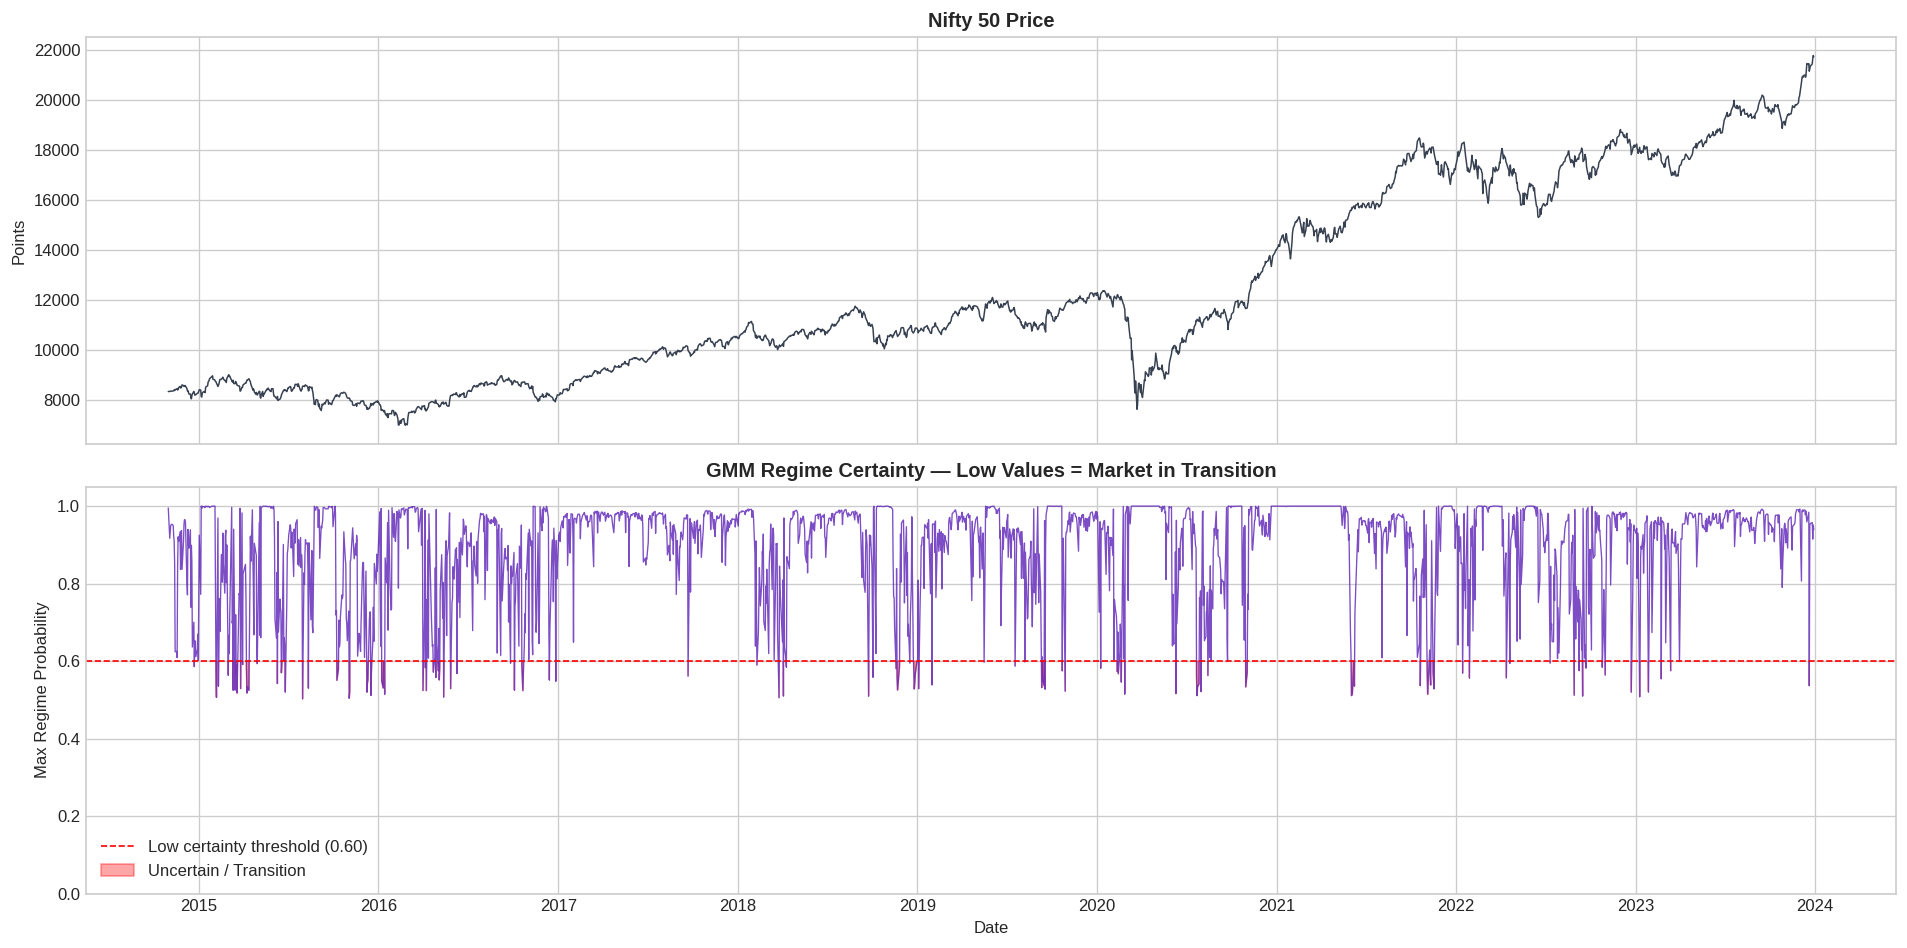

Transition days (certainty < 0.6): 129 days


In [15]:
max_prob = proba.max(axis=1)          # confidence for each day
df_clean['certainty'] = max_prob

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top: Nifty 50 price
axes[0].plot(df_clean.index, df_clean['Close'], color='#374151', lw=0.9)
axes[0].set_title('Nifty 50 Price', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Points')

# Bottom: GMM certainty (low certainty = transition period)
axes[1].plot(df_clean.index, df_clean['certainty'], color='#5B21B6', lw=0.8, alpha=0.8)
axes[1].axhline(0.60, color='red', lw=1, linestyle='--', label='Low certainty threshold (0.60)')
axes[1].fill_between(df_clean.index, df_clean['certainty'], 0.60,
    where=df_clean['certainty'] < 0.60, alpha=0.35, color='red', label='Uncertain / Transition')
axes[1].set_title('GMM Regime Certainty — Low Values = Market in Transition',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Max Regime Probability')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('07_regime_certainty.png', dpi=150, bbox_inches='tight')
plt.show()

print('Transition days (certainty < 0.6):',
      f'{(df_clean["certainty"] < 0.60).sum()} days')

### Step 16: Final Project Summary
Exporting a nice summary of our findings!

In [17]:
print('═' * 60)
print('  NIFTY 50 MARKET REGIME DETECTION')
print('  Using Gaussian Mixture Model (GMM)')
print('  PROJECT RESULTS SUMMARY')
print('═' * 60)

print('\n  DATASET')
print(f'    Index      :  Nifty 50 (NSE India)  —  Ticker: ^NSEI')
print(f'    Period     :  {df_clean.index[0].date()}  to  {df_clean.index[-1].date()}')
print(f'    Total days :  {len(df_clean)} NSE trading days')
print(f'    Features   :  log_return, volatility_20d, rsi, ma_ratio')

print('\n  GMM MODEL')
print(f'    Components (K)      :  3  (Bull, Bear, Sideways)')
print(f'    Covariance type     :  full  (each regime has own shape)')
print(f'    EM iterations used  :  {gmm.n_iter_}')
print(f'    Converged           :  {gmm.converged_}')
print(f'    BIC score           :  {gmm.bic(X_scaled):,.1f}')
print(f'    Silhouette Score    :  {sil:.4f}')

print('\n  REGIME DETECTION RESULTS')
for regime in ['Bull', 'Bear', 'Sideways']:
    subset = df_clean[df_clean['regime'] == regime]
    ct     = len(subset)
    pct    = ct / len(df_clean) * 100
    avg_r  = subset['log_return'].mean() * 100
    avg_v  = subset['volatility_20d'].mean() * 100
    avg_rs = subset['rsi'].mean()
    cert   = proba[df_clean['regime']==regime].max(axis=1).mean()
    print(f'\n    {regime}  ({ct} days, {pct:.1f}%)')
    print(f'      Avg log return : {avg_r:+.4f}%')
    print(f'      Avg volatility : {avg_v:.4f}%')
    print(f'      Avg RSI        : {avg_rs:.2f}')
    print(f'      Avg certainty  : {cert*100:.1f}%')

print(f'\n  TRANSITION / UNCERTAIN DAYS')
print(f'    {(df_clean["certainty"]<0.60).sum()} days had certainty below 60%')

print('\n  OUTPUT FILES')
for f in ['01_nifty50_raw.png', '02_nifty50_features.png',
          '03_gmm_bic_aic.png', '04_nifty50_regime_price.png',
          '05_regime_probability_stack.png',
          '06_volatility_by_regime.png', '07_regime_certainty.png']:
    print(f'    {f}')


════════════════════════════════════════════════════════════
  NIFTY 50 MARKET REGIME DETECTION
  Using Gaussian Mixture Model (GMM)
  PROJECT RESULTS SUMMARY
════════════════════════════════════════════════════════════

  DATASET
    Index      :  Nifty 50 (NSE India)  —  Ticker: ^NSEI
    Period     :  2014-10-31  to  2023-12-29
    Total days :  2254 NSE trading days
    Features   :  log_return, volatility_20d, rsi, ma_ratio

  GMM MODEL
    Components (K)      :  3  (Bull, Bear, Sideways)
    Covariance type     :  full  (each regime has own shape)
    EM iterations used  :  16
    Converged           :  True
    BIC score           :  21,270.8
    Silhouette Score    :  0.1582

  REGIME DETECTION RESULTS

    Bull  (1400 days, 62.1%)
      Avg log return : +0.0737%
      Avg volatility : 0.6710%
      Avg RSI        : 58.05
      Avg certainty  : 89.0%

    Bear  (64 days, 2.8%)
      Avg log return : -0.3608%
      Avg volatility : 3.2223%
      Avg RSI        : 48.50
      Avg 